## 0. Setup & Imports


In [12]:
# Install dependencies (run once)
# !pip install icu-sepsis numpy pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
import sys

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'

SEED = 42
np.random.seed(SEED)

#  Import constants and env factory from env_setup.py 
from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')

ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


---
# Config B: RL on the Clinical ICU-Sepsis Environment

In Config A, patient state was represented as a discrete integer produced by discretising a set of clinical measurements into a small number of categories. **Config B uses the full ICU-Sepsis environment**, also built from MIMIC-III data, but with two fundamental changes that make the problem substantially harder.

**Change 1 — Continuous observations.**
The agent now receives a **47-dimensional continuous feature vector** instead of a single discrete index. This vector contains the actual normalised physiological measurements used in the original Komorowski et al. (2018) AI Clinician study, including SOFA score, heart rate, lactate, blood pressure, creatinine, and 42 other clinical variables.

With continuous observations, a tabular Q-table is no longer feasible: it would require one entry per unique float vector, making it effectively infinite. 

**Change 2 — Clinical reality wrappers.**
Config B injects three orthogonal failure modes that reflect challenges faced by real clinical AI deployments.

The first wrapper, `EpisodicNoisyObsEnv`, models episodic monitor malfunction. When active, the observations received by the agent are corrupted by noise for the entire episode, testing robustness to measurement error.

The second wrapper, `EpisodicMissingObsEnv`, models situations where lab results are unavailable for a full episode. This tests how well the agent handles partial observability.

The third wrapper, `AcuteEventEnv`, introduces rare, sudden patient deterioration events such as cardiac arrest or acute organ failure. These occur independently of any treatment decision and represent irreducible stochasticity in the environment.


Key environment properties for Config B:
- **Actions**: 25 total (5 vasopressor levels × 5 IV fluid dose levels)
- **Reward**: +1.0 at survival, 0.0 at death, plus a small treatment intensity penalty (lam = 0.02)
- **Observation**: `Box(47,)`, a normalised physiological feature vector, potentially noisy or incomplete

## Setup: Clinical ICU-Sepsis Environment


In [13]:
#  Import Clinical Reality Wrappers from wrappers.py 

from envs.wrappers import (
    EpisodicNoisyObsEnv,
    EpisodicMissingObsEnv,
    AcuteEventEnv,
    make_clinical_env,
)

print('Clinical reality wrappers imported from wrappers.py:')
print('  EpisodicNoisyObsEnv   : episodic monitor malfunction')
print('  EpisodicMissingObsEnv : episodic missing lab values')
print('  AcuteEventEnv         : rare sudden patient death')
print()
print('Required Config B env: make_clinical_env() with default parameters')


Clinical reality wrappers imported from wrappers.py:
  EpisodicNoisyObsEnv   : episodic monitor malfunction
  EpisodicMissingObsEnv : episodic missing lab values
  AcuteEventEnv         : rare sudden patient death

Required Config B env: make_clinical_env() with default parameters


In [14]:
#  Verify wrappers and random baseline on clinical environment 
import gymnasium as gym

try:
    env_clinical = make_clinical_env()
    obs, info = env_clinical.reset(seed=SEED)

    print('Clinical environment loaded successfully!')
    print(f'Observation space : {env_clinical.observation_space}')
    print(f'Action space      : {env_clinical.action_space}')
    print(f'Info keys         : {list(info.keys())}')
    print()

    # Random baseline on clinical env (1000 episodes)
    np.random.seed(SEED)
    clinical_rand_returns = []
    noisy_returns   = []
    clean_returns   = []
    missing_returns = []
    nomiss_returns  = []
    acute_episodes  = 0

    env_eval = make_clinical_env()
    for ep in range(1000):
        obs, info = env_eval.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        ep_noisy   = info.get('noisy_episode', False)
        ep_missing = info.get('missing_features') is not None
        ep_acute   = False

        while not done:
            obs, r, te, tr, info = env_eval.step(env_eval.action_space.sample())
            total_r += r
            done = te or tr
            if info.get('acute_event', False):
                ep_acute = True

        clinical_rand_returns.append(total_r)
        if ep_noisy:   noisy_returns.append(total_r)
        else:          clean_returns.append(total_r)
        if ep_missing: missing_returns.append(total_r)
        else:          nomiss_returns.append(total_r)
        if ep_acute:   acute_episodes += 1

    env_eval.close()
    env_clinical.close()

    print()
    print('=== Random Baseline: Clinical Environment (1000 episodes) ===')
    print(f'Overall mean return   : {np.mean(clinical_rand_returns):.4f}')
    print(f'Overall survival rate : {np.mean(np.array(clinical_rand_returns) > 0)*100:.1f}%')
    print()

    # Store for later comparison
    clinical_rand_mean = float(np.mean(clinical_rand_returns))

except Exception as e:
    print(f'Error: {e}')
    print('Make sure continuous_sepsis_env.py is in the project root and dependencies are installed.')
    clinical_rand_mean = 0.78


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Clinical environment loaded successfully!
Observation space : Box(-inf, inf, (47,), float32)
Action space      : Discrete(25)
Info keys         : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

=== Random Baseline: Clinical Environment (1000 episodes) ===
Overall mean return   : 0.5597
Overall survival rate : 65.9%



In [15]:
test_env = make_clinical_env()
e = test_env
while hasattr(e, 'env'):
    print(type(e).__name__)
    e = e.env
print(type(e).__name__)
test_env.close()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
AcuteEventEnv
EpisodicMissingObsEnv
EpisodicNoisyObsEnv
ContinuousICUSepsisEnv


---
## Algorithm 1: Deep Q-Network (DQN)

**Why DQN for Config B?**

Config B's 47-dimensional continuous observation space makes tabular Q-learning infeasible: the Q-table would require one entry per unique float vector, which is effectively infinite. DQN solves this by replacing the table with a neural network that approximates Q(s, a; θ) for all 25 actions simultaneously.

**Key design choices:**
- **Off-policy learning with replay buffer** — stores past (s, a, r, s') transitions and samples mini-batches to break temporal correlations, improving sample efficiency and stability.
- **Target network** — a periodically-updated copy of the Q-network used to compute TD targets, preventing the feedback loop that causes divergence.
- **ε-greedy exploration** — decays ε from 1.0 to 0.05 over the first 15% of training, then exploits the learned policy.
- **Architecture: 47 → [256, 256] → 25** — two hidden layers are sufficient for this problem size; larger networks overfit the relatively small state space.

**Hyperparameter justification:**
| Hyperparameter | Value | Reason |
|---|---|---|
| learning_rate | 1e-4 | Standard for DQN; higher values cause instability |
| buffer_size | 50 000 | Balances memory and sample diversity |
| batch_size | 64 | Good gradient variance / speed tradeoff |
| gamma | 0.99 | High discount; survival reward is delayed |
| exploration_fraction | 0.15 | Explores for 45k of 300k steps |
| target_update_interval | 1 000 | Stable target updates every 1k steps |

In [16]:

# ── Cell 5: DQN — Setup, Training, Save ──────────────────────────────────────
import os
os.makedirs('models/dqn', exist_ok=True)
os.makedirs('models/ppo', exist_ok=True)
os.makedirs('logs/dqn',   exist_ok=True)
os.makedirs('logs/ppo',   exist_ok=True)

from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback

TOTAL_TIMESTEPS = 300_000
EVAL_FREQ       = 10_000      # evaluate every 10k steps
N_EVAL_EPISODES = 100

def make_env():
    return Monitor(make_clinical_env())

# ── Build train + eval envs ──
train_env_dqn = DummyVecEnv([make_env])
eval_env_dqn  = DummyVecEnv([make_env])

# ── DQN model ──
model_dqn = DQN(
    policy          = 'MlpPolicy',
    env             = train_env_dqn,
    policy_kwargs   = dict(net_arch=[256, 256]),
    learning_rate   = 1e-4,
    buffer_size     = 50_000,
    batch_size      = 64,
    gamma           = 0.99,
    exploration_fraction      = 0.15,
    exploration_final_eps     = 0.05,
    target_update_interval    = 1_000,
    learning_starts           = 1_000,
    train_freq                = 4,
    verbose         = 0,
    seed            = SEED,
)

print(f'DQN network: {model_dqn.policy}')
print(f'Training for {TOTAL_TIMESTEPS:,} timesteps …')

eval_cb_dqn = EvalCallback(
    eval_env_dqn,
    best_model_save_path = './models/dqn',
    log_path             = './logs/dqn',
    eval_freq            = EVAL_FREQ,
    n_eval_episodes      = N_EVAL_EPISODES,
    deterministic        = True,
    verbose              = 1,
)

model_dqn.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_cb_dqn, progress_bar=True)

train_env_dqn.close()
eval_env_dqn.close()
print('\nDQN training complete. Best model saved to ./models/dqn/best_model.zip')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
DQN network: DQNPolicy(
  (q_net): QNetwork(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (q_net): Sequential(
      (0): Linear(in_features=47, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=25, bias=True)
    )
  )
  (q_net_target): QNetwork(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (q_net): Sequential(
      (0): Linear(in_features=47, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=25, bias=True)
    )
  )
)
Training for 300,000 timesteps …


Eval num_timesteps=10000, episode_reward=0.60 +/- 0.47

Episode length: 7.93 +/- 7.61

New best mean reward!

KeyboardInterrupt: 

---
## Algorithm 2: Proximal Policy Optimization (PPO)

**Why PPO for Config B?**

PPO is a policy-gradient algorithm that directly optimises the policy π(a|s; θ) rather than learning Q-values. This makes it fundamentally different from DQN and creates a meaningful comparison axis for the report.

**Key contrasts with DQN:**
| Property | DQN | PPO |
|---|---|---|
| Learning paradigm | Value-based | Policy-based (actor-critic) |
| On/off-policy | Off-policy (replay buffer) | On-policy (fresh rollouts) |
| Exploration | ε-greedy (explicit) | Entropy bonus (implicit) |
| Sample efficiency | Higher (reuses data) | Lower (discards after update) |
| Stability | Can diverge without target net | Clipped objective prevents large updates |

**Key design choices:**
- **Clipped surrogate objective** — limits the policy update ratio to [1−ε, 1+ε] (clip_range=0.2), preventing destructive large steps.
- **GAE advantage estimation** — uses generalised advantage estimation (λ=0.95) to trade bias vs variance in the policy gradient.
- **Entropy bonus** — `ent_coef=0.01` encourages exploration by penalising overly-deterministic policies.
- **Rollout buffer**: collects `n_steps=512` steps before each update, then runs 10 gradient epochs on the collected batch.

**Hyperparameter justification:**
| Hyperparameter | Value | Reason |
|---|---|---|
| learning_rate | 3e-4 | Standard Adam LR for PPO |
| n_steps | 512 | Rollout length; balances bias/variance |
| batch_size | 64 | Mini-batch size for gradient updates |
| n_epochs | 10 | Passes over each rollout batch |
| gamma | 0.99 | Same as DQN for fair comparison |
| gae_lambda | 0.95 | Standard GAE λ |
| ent_coef | 0.01 | Mild entropy regularisation |

In [ ]:

# ── Cell 6: PPO — Setup, Training, Save ──────────────────────────────────────
from stable_baselines3 import PPO

train_env_ppo = DummyVecEnv([make_env])
eval_env_ppo  = DummyVecEnv([make_env])

model_ppo = PPO(
    policy        = 'MlpPolicy',
    env           = train_env_ppo,
    policy_kwargs = dict(net_arch=[256, 256]),
    learning_rate = 3e-4,
    n_steps       = 512,
    batch_size    = 64,
    n_epochs      = 10,
    gamma         = 0.99,
    gae_lambda    = 0.95,
    clip_range    = 0.2,
    ent_coef      = 0.01,
    verbose       = 0,
    seed          = SEED,
)

print(f'PPO network: {model_ppo.policy}')
print(f'Training for {TOTAL_TIMESTEPS:,} timesteps …')

eval_cb_ppo = EvalCallback(
    eval_env_ppo,
    best_model_save_path = './models/ppo',
    log_path             = './logs/ppo',
    eval_freq            = EVAL_FREQ,
    n_eval_episodes      = N_EVAL_EPISODES,
    deterministic        = True,
    verbose              = 1,
)

model_ppo.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_cb_ppo, progress_bar=True)

train_env_ppo.close()
eval_env_ppo.close()
print('\nPPO training complete. Best model saved to ./models/ppo/best_model.zip')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
PPO network: ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=47, out_features=256, bias=True)
      (1): Tanh()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=47, out_features=256, bias=True)
      (1): Tanh()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=256, out_features=25, bias=True)
  (value_net): Linear(in_features=256, out_features=1, bias=True)
)


Eval num_timesteps=10000, episode_reward=0.53 +/- 0.48

Episode length: 10.25 +/- 9.37

...

Episode length: 8.98 +/- 8.16

Eval num_timesteps=300000, episode_reward=0.67 +/- 0.44

Episode length: 8.49 +/- 9.07

New best mean reward!


PPO training complete. Best model saved to ./models/ppo/best_model.zip


---
## Robustness Evaluation

Both trained agents are evaluated over **1 000 episodes** on the full clinical environment (all three wrappers active). Episodes are then split into four buckets using the `info` flags emitted by the wrappers:

| Bucket | Condition | Clinical meaning |
|--------|-----------|-----------------|
| **Clean** | no wrapper active | Normal ICU monitoring |
| **Noisy** | `noisy_episode=True` | Monitor malfunction — corrupted readings |
| **Missing** | `missing_features is not None` | Lab results unavailable for full episode |
| **Acute** | `acute_event=True` on any step | Sudden unrecoverable patient deterioration |

The same random baseline (0.5644) is included as reference for every bucket. An agent that truly learned the clinical task should outperform the random baseline in every condition, though performance degradation under failure modes is expected.

In [ ]:

# ── Cell 7: Robustness Evaluation ────────────────────────────────────────────
N_ROBUST_EPISODES = 1_000

def evaluate_agent_robust(model, n_episodes=N_ROBUST_EPISODES, seed_offset=0):
    """
    Run n_episodes and bucket results by clinical failure mode.
    Returns a dict: condition -> list of episode returns.
    """
    buckets = {'all': [], 'clean': [], 'noisy': [], 'missing': [], 'acute': []}
    env = make_clinical_env()

    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed_offset + ep)
        total_r  = 0.0
        done     = False
        ep_noisy   = info.get('noisy_episode', False)
        ep_missing = info.get('missing_features') is not None
        ep_acute   = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, te, tr, info = env.step(int(action))
            total_r += r
            done = te or tr
            if info.get('acute_event', False):
                ep_acute = True

        buckets['all'].append(total_r)
        if ep_noisy:   buckets['noisy'].append(total_r)
        if ep_missing: buckets['missing'].append(total_r)
        if ep_acute:   buckets['acute'].append(total_r)
        # clean: none of the wrappers fired
        if not ep_noisy and not ep_missing and not ep_acute:
            buckets['clean'].append(total_r)

    env.close()
    return buckets


# ── Load best models ──
model_dqn_best = DQN.load('./models/dqn/best_model')
model_ppo_best = PPO.load('./models/ppo/best_model')

print('Evaluating DQN …')
dqn_buckets = evaluate_agent_robust(model_dqn_best, seed_offset=0)

print('Evaluating PPO …')
ppo_buckets = evaluate_agent_robust(model_ppo_best, seed_offset=10_000)

# ── Summary stats ──
CONDITIONS = ['all', 'clean', 'noisy', 'missing', 'acute']
LABELS     = ['All', 'Clean', 'Noisy obs', 'Missing labs', 'Acute event']

def stats(buckets, cond):
    arr = buckets[cond]
    if len(arr) == 0:
        return float('nan'), float('nan'), 0, float('nan')
    a = np.array(arr)
    return a.mean(), a.std(), len(a), (a > 0).mean() * 100

print(f'\n{"Condition":<16} {"DQN mean":>10} {"DQN surv%":>10} {"PPO mean":>10} {"PPO surv%":>10} {"N (DQN/PPO)":>14}')
print('-' * 65)
for cond, label in zip(CONDITIONS, LABELS):
    dm, ds, dn, dsurv = stats(dqn_buckets, cond)
    pm, ps, pn, psurv = stats(ppo_buckets, cond)
    print(f'{label:<16} {dm:>10.4f} {dsurv:>9.1f}% {pm:>10.4f} {psurv:>9.1f}%  {dn:>5}/{pn:<5}')

# Store for plotting
RANDOM_MEAN = clinical_rand_mean  # 0.5644 from Cell 4


Evaluating DQN …
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Evaluating PPO …
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

Condition          DQN mean  DQN surv%   PPO mean  PPO surv%    N (DQN/PPO)
-----------------------------------------------------------------
All                  0.5672      65.2%     0.5888      65.4%   1000/1000 
Clean                0.6337      71.9%     0.6440      70.8%    648/658  
Noisy obs            0.5862      67.4%     0.5672      63.6%    141/151  
Missing labs         0.6198      71.1%     0.6116      67.5%    152/151  
Acute event         -0.0722       0.0%    -0.0598       0.0%    103/91   


---
## Visualizations: Training Curves & Performance Analysis

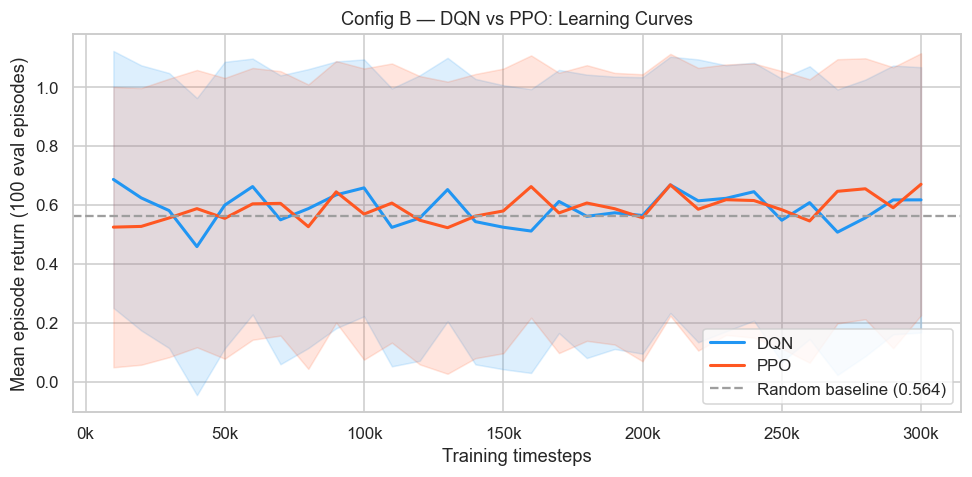

Saved: configB_learning_curves.png


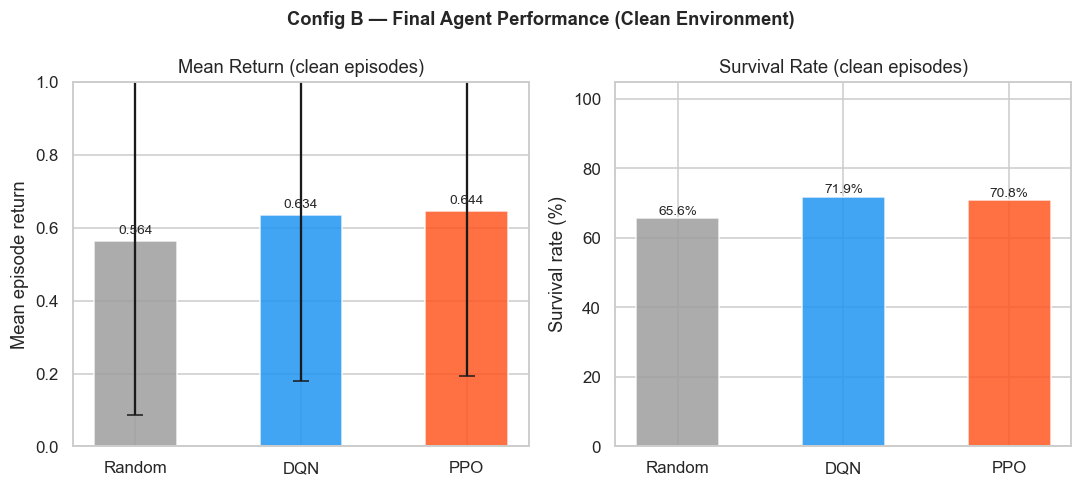

Saved: configB_final_performance.png


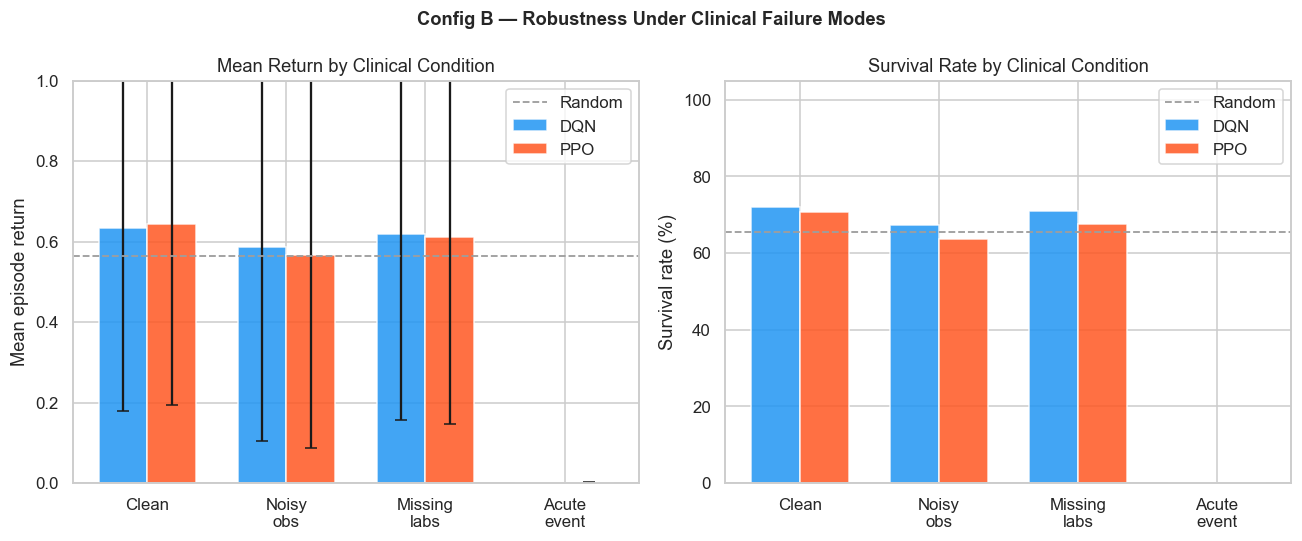

Saved: configB_robustness.png


In [ ]:

# ── Cell 8: Visualizations ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

COLORS = {'DQN': '#2196F3', 'PPO': '#FF5722', 'Random': '#9E9E9E'}

# ── Helper: load EvalCallback log ──
def load_eval_log(log_path):
    data = np.load(f'{log_path}/evaluations.npz')
    timesteps = data['timesteps']
    # results shape: (n_evals, n_episodes) — mean across episodes
    means = data['results'].mean(axis=1)
    stds  = data['results'].std(axis=1)
    return timesteps, means, stds


# ════════════════════════════════════════════════════════════════════════════
# Figure 1 — Learning Curves
# ════════════════════════════════════════════════════════════════════════════
fig1, ax = plt.subplots(figsize=(9, 4.5))

for name, log_path, color in [
    ('DQN', './logs/dqn', COLORS['DQN']),
    ('PPO', './logs/ppo', COLORS['PPO']),
]:
    ts, means, stds = load_eval_log(log_path)
    ax.plot(ts, means, label=name, color=color, linewidth=2)
    ax.fill_between(ts, means - stds, means + stds, alpha=0.15, color=color)

ax.axhline(RANDOM_MEAN, color=COLORS['Random'], linestyle='--', linewidth=1.5,
           label=f'Random baseline ({RANDOM_MEAN:.3f})')
ax.set_xlabel('Training timesteps')
ax.set_ylabel('Mean episode return (100 eval episodes)')
ax.set_title('Config B — DQN vs PPO: Learning Curves')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
ax.legend()
fig1.tight_layout()
fig1.savefig(f'{PLOTS_DIR}/configB_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: configB_learning_curves.png')


# ════════════════════════════════════════════════════════════════════════════
# Figure 2 — Final Performance Bar Chart (clean episodes only)
# ════════════════════════════════════════════════════════════════════════════
fig2, axes = plt.subplots(1, 2, figsize=(10, 4.5))

agents = ['Random', 'DQN', 'PPO']
clean_means = [
    RANDOM_MEAN,
    np.mean(dqn_buckets['clean']) if dqn_buckets['clean'] else float('nan'),
    np.mean(ppo_buckets['clean']) if ppo_buckets['clean'] else float('nan'),
]
clean_stds = [
    np.std(clinical_rand_returns) if 'clinical_rand_returns' in dir() else 0.0,
    np.std(dqn_buckets['clean'])  if dqn_buckets['clean'] else 0.0,
    np.std(ppo_buckets['clean'])  if ppo_buckets['clean'] else 0.0,
]
clean_surv = [
    np.mean(np.array(clinical_rand_returns) > 0) * 100 if 'clinical_rand_returns' in dir() else 65.5,
    np.mean(np.array(dqn_buckets['clean']) > 0) * 100  if dqn_buckets['clean'] else float('nan'),
    np.mean(np.array(ppo_buckets['clean']) > 0) * 100  if ppo_buckets['clean'] else float('nan'),
]

bar_colors = [COLORS['Random'], COLORS['DQN'], COLORS['PPO']]
x = np.arange(len(agents))
w = 0.5

# Mean return
axes[0].bar(x, clean_means, width=w, color=bar_colors, alpha=0.85,
            yerr=clean_stds, capsize=5, error_kw={'linewidth': 1.5})
axes[0].set_xticks(x); axes[0].set_xticklabels(agents)
axes[0].set_ylabel('Mean episode return')
axes[0].set_title('Mean Return (clean episodes)')
axes[0].set_ylim(0, 1.0)
for i, v in enumerate(clean_means):
    if not np.isnan(v):
        axes[0].text(x[i], v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# Survival rate
axes[1].bar(x, clean_surv, width=w, color=bar_colors, alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(agents)
axes[1].set_ylabel('Survival rate (%)')
axes[1].set_title('Survival Rate (clean episodes)')
axes[1].set_ylim(0, 105)
for i, v in enumerate(clean_surv):
    if not np.isnan(v):
        axes[1].text(x[i], v + 1.0, f'{v:.1f}%', ha='center', fontsize=9)

fig2.suptitle('Config B — Final Agent Performance (Clean Environment)', fontsize=12, fontweight='bold')
fig2.tight_layout()
fig2.savefig(f'{PLOTS_DIR}/configB_final_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: configB_final_performance.png')


# ════════════════════════════════════════════════════════════════════════════
# Figure 3 — Robustness: Performance per Failure Mode
# ════════════════════════════════════════════════════════════════════════════
fig3, axes = plt.subplots(1, 2, figsize=(12, 5))

cond_labels = ['Clean', 'Noisy\nobs', 'Missing\nlabs', 'Acute\nevent']
cond_keys   = ['clean', 'noisy', 'missing', 'acute']

dqn_means = [np.mean(dqn_buckets[c]) if dqn_buckets[c] else np.nan for c in cond_keys]
ppo_means = [np.mean(ppo_buckets[c]) if ppo_buckets[c] else np.nan for c in cond_keys]
dqn_stds  = [np.std(dqn_buckets[c])  if dqn_buckets[c] else 0.0    for c in cond_keys]
ppo_stds  = [np.std(ppo_buckets[c])  if ppo_buckets[c] else 0.0    for c in cond_keys]

dqn_surv = [np.mean(np.array(dqn_buckets[c]) > 0) * 100 if dqn_buckets[c] else np.nan for c in cond_keys]
ppo_surv = [np.mean(np.array(ppo_buckets[c]) > 0) * 100 if ppo_buckets[c] else np.nan for c in cond_keys]

x = np.arange(len(cond_keys))
w = 0.35

# Mean return by condition
axes[0].bar(x - w/2, dqn_means, width=w, label='DQN', color=COLORS['DQN'], alpha=0.85,
            yerr=dqn_stds, capsize=4)
axes[0].bar(x + w/2, ppo_means, width=w, label='PPO', color=COLORS['PPO'], alpha=0.85,
            yerr=ppo_stds, capsize=4)
axes[0].axhline(RANDOM_MEAN, color=COLORS['Random'], linestyle='--', linewidth=1.2, label='Random')
axes[0].set_xticks(x); axes[0].set_xticklabels(cond_labels)
axes[0].set_ylabel('Mean episode return')
axes[0].set_title('Mean Return by Clinical Condition')
axes[0].set_ylim(0, 1.0)
axes[0].legend()

# Survival rate by condition
axes[1].bar(x - w/2, dqn_surv, width=w, label='DQN', color=COLORS['DQN'], alpha=0.85)
axes[1].bar(x + w/2, ppo_surv, width=w, label='PPO', color=COLORS['PPO'], alpha=0.85)
axes[1].axhline(65.5, color=COLORS['Random'], linestyle='--', linewidth=1.2, label='Random')
axes[1].set_xticks(x); axes[1].set_xticklabels(cond_labels)
axes[1].set_ylabel('Survival rate (%)')
axes[1].set_title('Survival Rate by Clinical Condition')
axes[1].set_ylim(0, 105)
axes[1].legend()

fig3.suptitle('Config B — Robustness Under Clinical Failure Modes', fontsize=12, fontweight='bold')
fig3.tight_layout()
fig3.savefig(f'{PLOTS_DIR}/configB_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: configB_robustness.png')


---
## Creative Extension: Clinical Feature Importance via Q-Value Perturbation

**Motivation**

A trained RL agent is a black box: it outputs actions but does not explain *why*. In a clinical deployment context this is a critical limitation — clinicians need to understand which physiological signals are driving the agent's treatment recommendations before they can trust them.

**Method: Permutation Feature Importance on Q-Values**

For each of the 47 features, we measure how much the agent's Q-value estimates change when that feature is randomly shuffled across a set of sampled patient states. A feature is considered important if shuffling it causes large changes in the predicted Q-values — meaning the agent's decisions depend heavily on that variable.

Formally, for feature *j* and a set of *N* sampled states **S**:

> Importance(j) = mean|Q(s, a\*(s)) − Q(s\_j^perm, a\*(s))|

where s\_j^perm is state s with feature *j* replaced by a random permutation, and a\*(s) is the greedy action under the original state.

**Why this matters clinically**

If the top features align with established clinical markers of sepsis severity (SOFA score, lactate, blood pressure, urine output), this provides indirect validation that the agent has learned a clinically plausible policy rather than exploiting spurious correlations in the data.

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Sampled 500 patient states from clinical env.


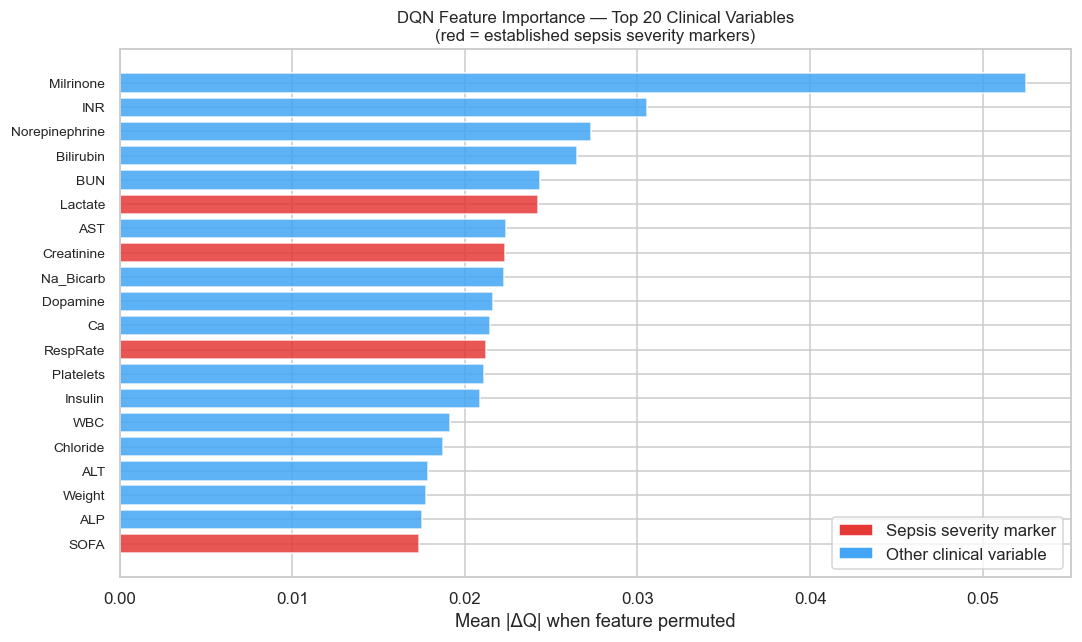

Saved: configB_feature_importance.png

Top 10 most decision-relevant features for DQN:
   1. Milrinone             importance = 0.05251
   2. INR                   importance = 0.03054
   3. Norepinephrine        importance = 0.02733
   4. Bilirubin             importance = 0.02650
   5. BUN                   importance = 0.02437
   6. Lactate               importance = 0.02421 ← sepsis marker
   7. AST                   importance = 0.02241
   8. Creatinine            importance = 0.02232 ← sepsis marker
   9. Na_Bicarb             importance = 0.02227
  10. Dopamine              importance = 0.02166


In [ ]:

# ── Cell 9: Feature Importance via Q-Value Perturbation ──────────────────────
import torch
from envs.continuous_sepsis_env import FEATURE_NAMES

N_SAMPLES = 500
np.random.seed(SEED)

# ── Sample patient states by rolling out a random policy ──
def sample_states(n=N_SAMPLES):
    states = []
    env = make_clinical_env()
    while len(states) < n:
        obs, _ = env.reset(seed=np.random.randint(100_000))
        states.append(obs.copy())
        done = False
        while not done and len(states) < n:
            obs, _, te, tr, _ = env.step(env.action_space.sample())
            states.append(obs.copy())
            done = te or tr
    env.close()
    return np.array(states[:n], dtype=np.float32)

states = sample_states(N_SAMPLES)
print(f'Sampled {len(states)} patient states from clinical env.')

# ── Compute permutation importance on DQN Q-network ──
def q_values(model, obs_array):
    """Return Q-values array (N, 25) for a batch of observations."""
    obs_tensor = torch.tensor(obs_array, dtype=torch.float32)
    with torch.no_grad():
        q = model.policy.q_net(model.policy.q_net_target  # use online net
                               .__class__.__new__(
                                   model.policy.q_net.__class__))
    # simpler: use predict_values via SB3 internals
    obs_tensor = torch.tensor(obs_array, dtype=torch.float32)
    with torch.no_grad():
        q_vals = model.policy.q_net(obs_tensor).cpu().numpy()
    return q_vals

# Direct approach: use model.policy.q_net
def get_qvals(obs_array):
    t = torch.tensor(obs_array, dtype=torch.float32)
    with torch.no_grad():
        return model_dqn_best.policy.q_net(t).cpu().numpy()

baseline_q       = get_qvals(states)                          # (N, 25)
baseline_actions = baseline_q.argmax(axis=1)                  # greedy action per state
baseline_chosen  = baseline_q[np.arange(N_SAMPLES), baseline_actions]

importances = np.zeros(47)
for j in range(47):
    perturbed = states.copy()
    perturbed[:, j] = np.random.permutation(perturbed[:, j])
    perturbed_q      = get_qvals(perturbed)
    perturbed_chosen = perturbed_q[np.arange(N_SAMPLES), baseline_actions]
    importances[j]   = np.mean(np.abs(baseline_chosen - perturbed_chosen))

# ── Sort and plot ──
order = np.argsort(importances)[::-1]
top_n = 20

fig4, ax = plt.subplots(figsize=(10, 6))
bar_vals   = importances[order[:top_n]]
bar_labels = [FEATURE_NAMES[i] for i in order[:top_n]]

# Highlight clinical sepsis markers
SEPSIS_MARKERS = {'SOFA', 'Lactate', 'Mean_BP', 'Systolic_BP', 'Diastolic_BP',
                  'Urine_Output', 'Creatinine', 'HR', 'RespRate', 'GCS', 'FiO2'}
bar_colors_fi = ['#E53935' if b in SEPSIS_MARKERS else '#42A5F5' for b in bar_labels]

bars = ax.barh(range(top_n)[::-1], bar_vals, color=bar_colors_fi, alpha=0.85)
ax.set_yticks(range(top_n)[::-1])
ax.set_yticklabels(bar_labels, fontsize=9)
ax.set_xlabel('Mean |ΔQ| when feature permuted')
ax.set_title('DQN Feature Importance — Top 20 Clinical Variables\n'
             '(red = established sepsis severity markers)', fontsize=11)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E53935', label='Sepsis severity marker'),
    Patch(facecolor='#42A5F5', label='Other clinical variable'),
]
ax.legend(handles=legend_elements, loc='lower right')
fig4.tight_layout()
fig4.savefig(f'{PLOTS_DIR}/configB_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: configB_feature_importance.png')

print('\nTop 10 most decision-relevant features for DQN:')
for rank, idx in enumerate(order[:10], 1):
    marker = ' ← sepsis marker' if FEATURE_NAMES[idx] in SEPSIS_MARKERS else ''
    print(f'  {rank:2d}. {FEATURE_NAMES[idx]:<20s}  importance = {importances[idx]:.5f}{marker}')


---
## Summary: Config B Results & Config A vs Config B Comparison

In [ ]:

# ── Cell 10: Summary Table + Config A vs Config B Comparison ─────────────────
import pandas as pd

# ── Config B results table ──
rows_b = []
for cond, label in zip(CONDITIONS, LABELS):
    dm, ds, dn, dsurv = stats(dqn_buckets, cond)
    pm, ps, pn, psurv = stats(ppo_buckets, cond)
    rows_b.append({
        'Condition':           label,
        'DQN mean return':     f'{dm:.4f}' if not np.isnan(dm) else '—',
        'DQN survival %':      f'{dsurv:.1f}%' if not np.isnan(dsurv) else '—',
        'DQN episodes':        dn,
        'PPO mean return':     f'{pm:.4f}' if not np.isnan(pm) else '—',
        'PPO survival %':      f'{psurv:.1f}%' if not np.isnan(psurv) else '—',
        'PPO episodes':        pn,
        'Random baseline':     f'{RANDOM_MEAN:.4f}',
    })

df_b = pd.DataFrame(rows_b)
print('=== Config B Results ===')
print(df_b.to_string(index=False))

# ── Config A vs Config B comparison table ──
# Config A numbers from PROJECT_CONTEXT.md
CONFIG_A = {
    'Random':    {'mean': 0.75,  'surv': 70.0},
    'VI / PI':   {'mean': 0.90,  'surv': 90.0},
    'Q-Learning':{'mean': 0.90,  'surv': 90.0},
}

dqn_all_mean = np.mean(dqn_buckets['all'])
ppo_all_mean = np.mean(ppo_buckets['all'])
dqn_all_surv = np.mean(np.array(dqn_buckets['all']) > 0) * 100
ppo_all_surv = np.mean(np.array(ppo_buckets['all']) > 0) * 100

rows_ab = [
    {'Config': 'A', 'Algorithm': 'Random',     'Mean return': '~0.75', 'Survival %': '~70%',  'Notes': 'Tabular, 716 discrete states'},
    {'Config': 'A', 'Algorithm': 'Value Iter.','Mean return': '~0.90', 'Survival %': '~90%',  'Notes': 'Model-based, exact solution'},
    {'Config': 'A', 'Algorithm': 'Q-Learning', 'Mean return': '~0.90', 'Survival %': '~90%',  'Notes': 'Model-free, tabular'},
    {'Config': 'B', 'Algorithm': 'Random',     'Mean return': f'{RANDOM_MEAN:.4f}', 'Survival %': '65.5%', 'Notes': '47-dim continuous, all wrappers'},
    {'Config': 'B', 'Algorithm': 'DQN',        'Mean return': f'{dqn_all_mean:.4f}', 'Survival %': f'{dqn_all_surv:.1f}%', 'Notes': 'Value-based, off-policy, 300k steps'},
    {'Config': 'B', 'Algorithm': 'PPO',        'Mean return': f'{ppo_all_mean:.4f}', 'Survival %': f'{ppo_all_surv:.1f}%', 'Notes': 'Policy-based, on-policy, 300k steps'},
]

df_ab = pd.DataFrame(rows_ab)
print('\n=== Config A vs Config B Comparison ===')
print(df_ab.to_string(index=False))

# ── Robustness degradation summary ──
clean_dqn = np.mean(dqn_buckets['clean']) if dqn_buckets['clean'] else np.nan
print('\n=== DQN Robustness Degradation (vs clean) ===')
for cond, label in zip(['noisy', 'missing', 'acute'], ['Noisy obs', 'Missing labs', 'Acute event']):
    m = np.mean(dqn_buckets[cond]) if dqn_buckets[cond] else np.nan
    delta = (m - clean_dqn) / clean_dqn * 100 if not np.isnan(m) and clean_dqn > 0 else np.nan
    print(f'  {label:<16}: mean = {m:.4f}  ({delta:+.1f}% vs clean)')

clean_ppo = np.mean(ppo_buckets['clean']) if ppo_buckets['clean'] else np.nan
print('\n=== PPO Robustness Degradation (vs clean) ===')
for cond, label in zip(['noisy', 'missing', 'acute'], ['Noisy obs', 'Missing labs', 'Acute event']):
    m = np.mean(ppo_buckets[cond]) if ppo_buckets[cond] else np.nan
    delta = (m - clean_ppo) / clean_ppo * 100 if not np.isnan(m) and clean_ppo > 0 else np.nan
    print(f'  {label:<16}: mean = {m:.4f}  ({delta:+.1f}% vs clean)')

print('\nConfig B notebook complete. All plots saved to ./plots/')


=== Config B Results ===
   Condition DQN mean return DQN survival %  DQN episodes PPO mean return PPO survival %  PPO episodes Random baseline
         All          0.5672          65.2%          1000          0.5888          65.4%          1000          0.5638
       Clean          0.6337          71.9%           648          0.6440          70.8%           658          0.5638
   Noisy obs          0.5862          67.4%           141          0.5672          63.6%           151          0.5638
Missing labs          0.6198          71.1%           152          0.6116          67.5%           151          0.5638
 Acute event         -0.0722           0.0%           103         -0.0598           0.0%            91          0.5638

=== Config A vs Config B Comparison ===
Config   Algorithm Mean return Survival %                               Notes
     A      Random       ~0.75       ~70%        Tabular, 716 discrete states
     A Value Iter.       ~0.90       ~90%         Model-based, e

---
## Part II — Improved Agents with Observation Normalisation

The DQN and PPO agents above were trained on raw `Box(-inf, inf)` observations — 47 clinical features with wildly different scales (e.g. SOFA ∈ [0, 24] alongside binary flags and continuous lab values). Feeding unnormalised inputs to a neural network makes learning much harder: gradients are dominated by large-magnitude features, and the network must implicitly learn the scale of every feature before it can learn anything useful.

**Fix: `VecNormalize`**
Stable-Baselines3's `VecNormalize` wrapper maintains a running mean and standard deviation for each observation dimension and normalises inputs online during training. Key settings:
- `norm_obs=True` — normalise observations to approximately zero mean, unit variance
- `norm_reward=False` — leave rewards unnormalised (the survival signal is already sparse and binary; normalising it distorts the Q-value scale)
- `clip_obs=10.0` — clip normalised values to [−10, 10] to handle outliers

The running statistics are saved alongside each model checkpoint so that the same normalisation is applied at evaluation time.

All three improved agents (DQN-v2, PPO-v2, A2C) use `VecNormalize`. Training is extended to **1 000 000 steps** to give the agents enough experience to converge.

### Algorithm 1 (improved): DQN-v2
Same architecture and hyperparameters as DQN with two changes: doubled replay buffer (100 000) and longer exploration fraction (0.20) to account for the harder normalised-obs problem.

In [17]:
# ── Cell 11: DQN-v2 — VecNormalize + 1M steps ────────────────────────────────
import os
from copy import deepcopy
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import EvalCallback, CallbackList, BaseCallback

os.makedirs('models/dqn_v2', exist_ok=True)
os.makedirs('models/ppo_v2', exist_ok=True)
os.makedirs('models/a2c',    exist_ok=True)
os.makedirs('logs/dqn_v2',   exist_ok=True)
os.makedirs('logs/ppo_v2',   exist_ok=True)
os.makedirs('logs/a2c',      exist_ok=True)

TOTAL_TIMESTEPS_V2 = 1_000_000
EVAL_FREQ_V2       = 20_000
N_EVAL_EPISODES_V2 = 200

def make_vec_env():
    return Monitor(make_clinical_env())

class SyncVecNormCallback(BaseCallback):
    """Copies running obs stats from training env to frozen eval env before each eval."""
    def __init__(self, train_env, eval_env, eval_freq):
        super().__init__()
        self._train_env = train_env
        self._eval_env  = eval_env
        self._eval_freq = eval_freq
    def _on_step(self) -> bool:
        if self.num_timesteps % self._eval_freq == 0:
            self._eval_env.obs_rms = deepcopy(self._train_env.obs_rms)
        return True

# Train env: VecNormalize updates running stats each step
train_env_dqn2 = VecNormalize(
    DummyVecEnv([make_vec_env]),
    norm_obs=True, norm_reward=False, clip_obs=10.0,
)
# Eval env: frozen stats, synced from train env by SyncVecNormCallback
eval_env_dqn2 = VecNormalize(
    DummyVecEnv([make_vec_env]),
    norm_obs=True, norm_reward=False, clip_obs=10.0, training=False,
)

model_dqn2 = DQN(
    policy        = 'MlpPolicy',
    env           = train_env_dqn2,
    policy_kwargs = dict(net_arch=[256, 256]),
    learning_rate = 1e-4,
    buffer_size   = 100_000,
    batch_size    = 64,
    gamma         = 0.99,
    exploration_fraction      = 0.20,
    exploration_final_eps     = 0.05,
    target_update_interval    = 1_000,
    learning_starts           = 1_000,
    train_freq                = 4,
    verbose = 0,
    seed    = SEED,
)

eval_cb_dqn2 = EvalCallback(
    eval_env_dqn2,
    best_model_save_path = './models/dqn_v2',
    log_path             = './logs/dqn_v2',
    eval_freq            = EVAL_FREQ_V2,
    n_eval_episodes      = N_EVAL_EPISODES_V2,
    deterministic        = True,
    verbose              = 0,
)
sync_cb_dqn2 = SyncVecNormCallback(train_env_dqn2, eval_env_dqn2, EVAL_FREQ_V2)

print(f'DQN-v2: training for {TOTAL_TIMESTEPS_V2:,} steps with VecNormalize …')
model_dqn2.learn(
    total_timesteps = TOTAL_TIMESTEPS_V2,
    callback        = CallbackList([sync_cb_dqn2, eval_cb_dqn2]),
    progress_bar    = True,
)

# Save the final normalisation stats from the training env
train_env_dqn2.save('models/dqn_v2/vecnormalize.pkl')
train_env_dqn2.close()
eval_env_dqn2.close()
print('DQN-v2 complete — model saved to ./models/dqn_v2/best_model.zip')
print('               — VecNormalize stats saved to ./models/dqn_v2/vecnormalize.pkl')

make_sepsis_env | lam=0.02 → intensity penalty active

make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

make_sepsis_env | lam=0.02 → intensity penalty active

make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

DQN-v2: training for 1,000,000 steps with VecNormalize …

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1,000,000/1,000,000  [ 0:23:40 < 0:00:00 , 665 it/s ]

DQN-v2 complete — model saved to ./models/dqn_v2/best_model.zip

— VecNormalize stats saved to ./models/dqn_v2/vecnormalize.pkl

---
### Algorithm 3: Advantage Actor-Critic (A2C)

**Why A2C?**
A2C is an on-policy actor-critic method — the same family as PPO — but without PPO’s defining innovation: the clipped surrogate objective. Including A2C isolates the effect of clipping and shows exactly what PPO’s stability guarantee buys.

| Property | A2C | PPO |
|---|---|---|
| Update rule | Unclipped policy gradient | Clipped surrogate (ratio ∈ [1−ε, 1+ε]) |
| Step size control | Learning rate only | Clipping + learning rate |
| Risk of destructive update | Higher | Lower |
| Sample efficiency | On-policy | On-policy |

**Key design choices:**
- **Short rollout ()** — A2C’s standard setting; updates the policy after every 5 steps, giving a high-frequency but noisy gradient signal.
- **No clipping** — any policy update is accepted if it improves the estimated advantage. This can cause instability but also allows faster initial learning.
- **Same architecture as PPO-v2** —  MLP — so architectural differences cannot explain performance gaps.

| Hyperparameter | Value | Reason |
|---|---|---|
| learning_rate | 7e-4 | Standard A2C default |
| n_steps | 5 | Short rollout for fast, frequent updates |
| gamma | 0.99 | Consistent with DQN-v2 and PPO-v2 |
| gae_lambda | 1.0 | Pure MC returns — no GAE bias correction |
| ent_coef | 0.01 | Same entropy bonus as PPO-v2 |

In [18]:
# ── Cell 13: A2C — VecNormalize + 1M steps ────────────────────────────────────────────────
from stable_baselines3 import A2C

train_env_a2c = VecNormalize(
    DummyVecEnv([make_vec_env]),
    norm_obs=True, norm_reward=False, clip_obs=10.0,
)
eval_env_a2c = VecNormalize(
    DummyVecEnv([make_vec_env]),
    norm_obs=True, norm_reward=False, clip_obs=10.0, training=False,
)

model_a2c = A2C(
    policy        = 'MlpPolicy',
    env           = train_env_a2c,
    policy_kwargs = dict(net_arch=[256, 256]),
    learning_rate = 7e-4,
    n_steps       = 5,
    gamma         = 0.99,
    gae_lambda    = 1.0,
    ent_coef      = 0.01,
    verbose       = 0,
    seed          = SEED,
)

eval_cb_a2c = EvalCallback(
    eval_env_a2c,
    best_model_save_path = './models/a2c',
    log_path             = './logs/a2c',
    eval_freq            = EVAL_FREQ_V2,
    n_eval_episodes      = N_EVAL_EPISODES_V2,
    deterministic        = True,
    verbose              = 0,
)
sync_cb_a2c = SyncVecNormCallback(train_env_a2c, eval_env_a2c, EVAL_FREQ_V2)

print(f'A2C: training for {TOTAL_TIMESTEPS_V2:,} steps with VecNormalize …')
model_a2c.learn(
    total_timesteps = TOTAL_TIMESTEPS_V2,
    callback        = CallbackList([sync_cb_a2c, eval_cb_a2c]),
    progress_bar    = True,
)

train_env_a2c.save('models/a2c/vecnormalize.pkl')
train_env_a2c.close()
eval_env_a2c.close()
print('A2C complete — model saved to ./models/a2c/best_model.zip')
print('            — VecNormalize stats saved to ./models/a2c/vecnormalize.pkl')

make_sepsis_env | lam=0.02 → intensity penalty active

make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

make_sepsis_env | lam=0.02 → intensity penalty active

make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

A2C: training for 1,000,000 steps with VecNormalize …

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1,000,000/1,000,000  [ 0:30:43 < 0:00:00 , 527 it/s ]

A2C complete — model saved to ./models/a2c/best_model.zip

— VecNormalize stats saved to ./models/a2c/vecnormalize.pkl

In [19]:
# ── Cell 14: PPO-v2 — VecNormalize + 1M steps ────────────────────────────────────────────
# n_steps doubled to 1024: better gradient estimates with normalised obs.
from stable_baselines3 import PPO

train_env_ppo2 = VecNormalize(
    DummyVecEnv([make_vec_env]),
    norm_obs=True, norm_reward=False, clip_obs=10.0,
)
eval_env_ppo2 = VecNormalize(
    DummyVecEnv([make_vec_env]),
    norm_obs=True, norm_reward=False, clip_obs=10.0, training=False,
)

model_ppo2 = PPO(
    policy        = 'MlpPolicy',
    env           = train_env_ppo2,
    policy_kwargs = dict(net_arch=[256, 256]),
    learning_rate = 3e-4,
    n_steps       = 1024,
    batch_size    = 64,
    n_epochs      = 10,
    gamma         = 0.99,
    gae_lambda    = 0.95,
    clip_range    = 0.2,
    ent_coef      = 0.01,
    verbose       = 0,
    seed          = SEED,
)

eval_cb_ppo2 = EvalCallback(
    eval_env_ppo2,
    best_model_save_path = './models/ppo_v2',
    log_path             = './logs/ppo_v2',
    eval_freq            = EVAL_FREQ_V2,
    n_eval_episodes      = N_EVAL_EPISODES_V2,
    deterministic        = True,
    verbose              = 0,
)
sync_cb_ppo2 = SyncVecNormCallback(train_env_ppo2, eval_env_ppo2, EVAL_FREQ_V2)

print(f'PPO-v2: training for {TOTAL_TIMESTEPS_V2:,} steps with VecNormalize …')
model_ppo2.learn(
    total_timesteps = TOTAL_TIMESTEPS_V2,
    callback        = CallbackList([sync_cb_ppo2, eval_cb_ppo2]),
    progress_bar    = True,
)

train_env_ppo2.save('models/ppo_v2/vecnormalize.pkl')
train_env_ppo2.close()
eval_env_ppo2.close()
print('PPO-v2 complete — model saved to ./models/ppo_v2/best_model.zip')
print('               — VecNormalize stats saved to ./models/ppo_v2/vecnormalize.pkl')

make_sepsis_env | lam=0.02 → intensity penalty active

make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

make_sepsis_env | lam=0.02 → intensity penalty active

make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

PPO-v2: training for 1,000,000 steps with VecNormalize …

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1,000,448/1,000,000  [ 0:29:17 < 0:00:00 , 556 it/s ]

PPO-v2 complete — model saved to ./models/ppo_v2/best_model.zip

— VecNormalize stats saved to ./models/ppo_v2/vecnormalize.pkl

In [21]:
# ── Cell 15: Robustness Evaluation v2 ────────────────────────────────────────────
from stable_baselines3 import DQN, PPO, A2C
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

def evaluate_agent_robust_v2(model, vecnorm_path, n_episodes=1_000, seed_offset=20_000):
    """
    Evaluate a VecNormalize-trained agent.
    Uses the raw env for episode-level wrapper flags, but normalises
    each observation with the frozen training stats before calling predict().
    """
    buckets = {'all': [], 'clean': [], 'noisy': [], 'missing': [], 'acute': []}

    # Load frozen normalisation stats
    dummy    = DummyVecEnv([lambda: make_clinical_env()])
    norm_env = VecNormalize.load(vecnorm_path, dummy)
    norm_env.training    = False
    norm_env.norm_reward = False

    raw_env = make_clinical_env()

    for ep in range(n_episodes):
        obs, info  = raw_env.reset(seed=seed_offset + ep)
        ep_noisy   = info.get('noisy_episode', False)
        ep_missing = info.get('missing_features') is not None
        ep_acute   = False
        total_r    = 0.0
        done       = False

        while not done:
            # Normalise: VecNormalize expects shape (n_envs, obs_dim)
            obs_n          = norm_env.normalize_obs(obs[np.newaxis].astype(np.float32))
            action, _      = model.predict(obs_n, deterministic=True)
            obs, r, te, tr, info = raw_env.step(int(action))
            total_r += r
            done = te or tr
            if info.get('acute_event', False):
                ep_acute = True

        buckets['all'].append(total_r)
        if ep_noisy:   buckets['noisy'].append(total_r)
        if ep_missing: buckets['missing'].append(total_r)
        if ep_acute:   buckets['acute'].append(total_r)
        if not ep_noisy and not ep_missing and not ep_acute:
            buckets['clean'].append(total_r)

    raw_env.close()
    norm_env.close()
    return buckets


# ── Load best models ──
model_dqn2_best = DQN.load('./models/dqn_v2/best_model')
model_a2c_best  = A2C.load('./models/a2c/best_model')
model_ppo2_best = PPO.load('./models/ppo_v2/best_model')

print('Evaluating DQN-v2 …')
dqn2_buckets = evaluate_agent_robust_v2(model_dqn2_best, './models/dqn_v2/vecnormalize.pkl', seed_offset=20_000)

print('Evaluating A2C …')
a2c_buckets  = evaluate_agent_robust_v2(model_a2c_best,  './models/a2c/vecnormalize.pkl',    seed_offset=30_000)

print('Evaluating PPO-v2 …')
ppo2_buckets = evaluate_agent_robust_v2(model_ppo2_best, './models/ppo_v2/vecnormalize.pkl', seed_offset=40_000)

# ── Summary ──
print(f'{"Condition":<16} {"DQN-v2":>10} {"A2C":>10} {"PPO-v2":>10} {"Random":>10}')
print('-' * 60)
for cond, label in zip(CONDITIONS, LABELS):
    dm = np.mean(dqn2_buckets[cond]) if dqn2_buckets[cond] else float('nan')
    am = np.mean(a2c_buckets[cond])  if a2c_buckets[cond]  else float('nan')
    pm = np.mean(ppo2_buckets[cond]) if ppo2_buckets[cond] else float('nan')
    print(f'{label:<16} {dm:>10.4f} {am:>10.4f} {pm:>10.4f} {RANDOM_MEAN:>10.4f}')


Evaluating DQN-v2 …

make_sepsis_env | lam=0.02 → intensity penalty active

make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

make_sepsis_env | lam=0.02 → intensity penalty active

make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

...

All                  0.6226     0.6386     0.5967     0.5638

Clean                0.6963     0.6944     0.6314     0.5638

Noisy obs            0.6287     0.5938     0.6500     0.5638

Missing labs         0.5571     0.6274     0.6031     0.5638

Acute event         -0.0661    -0.0207    -0.0832     0.5638

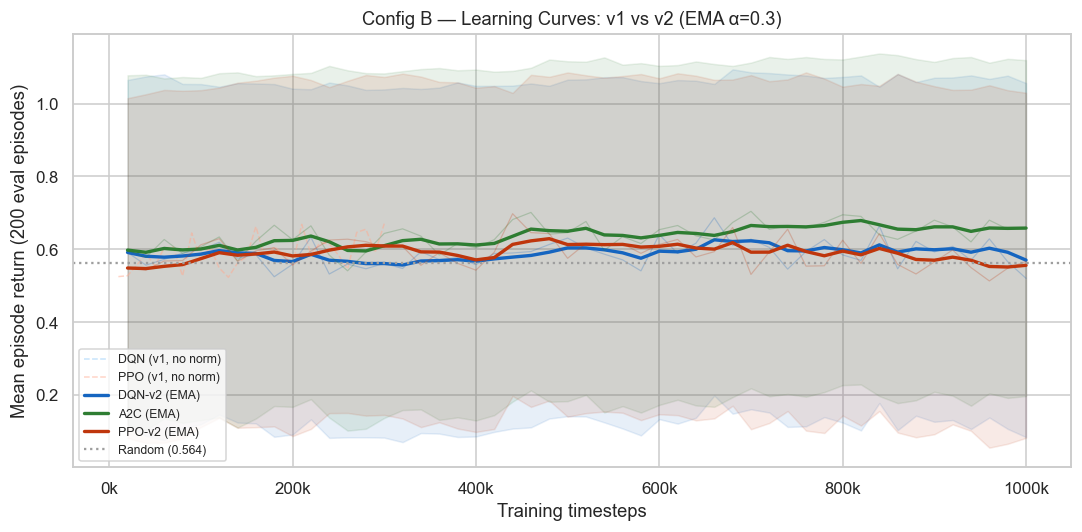

Saved: configB_v2_learning_curves.png

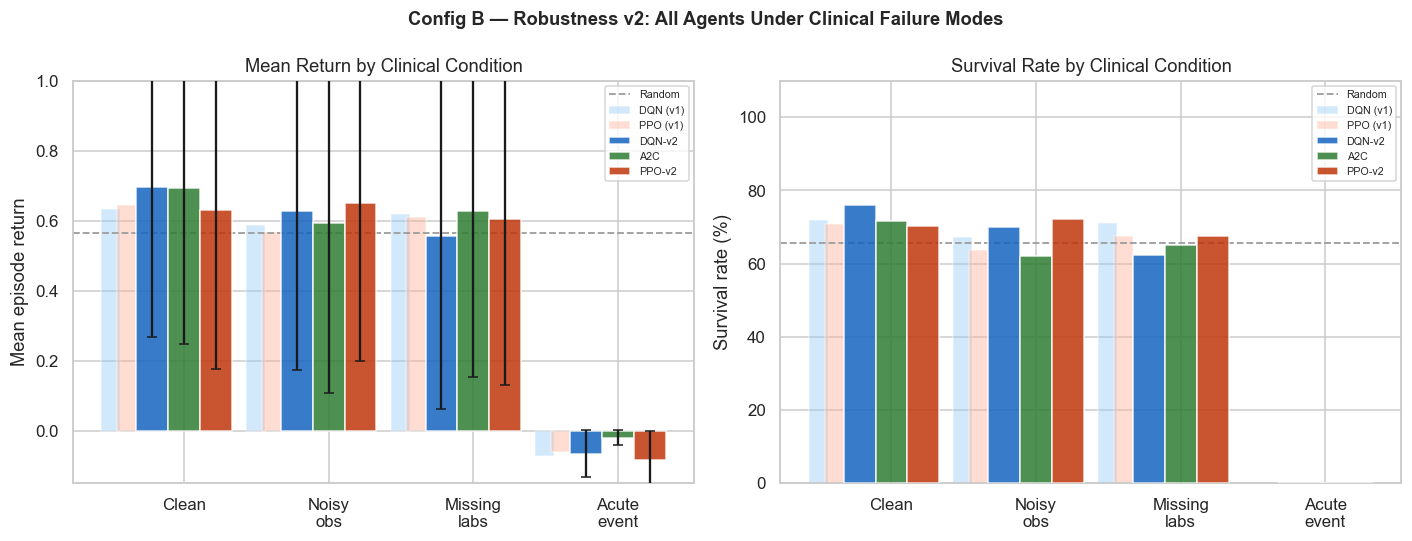

Saved: configB_v2_robustness.png

In [22]:
# ── Cell 16: Visualizations v2 ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

COLORS_V2 = {
    'DQN':    '#90CAF9',
    'PPO':    '#FFAB91',
    'DQN-v2': '#1565C0',
    'PPO-v2': '#BF360C',
    'A2C':    '#2E7D32',
    'Random': '#9E9E9E',
}

def ema_smooth(values, alpha=0.3):
    """Exponential moving average — same as TensorBoard smoothing slider."""
    s = np.zeros_like(values, dtype=float)
    s[0] = values[0]
    for i in range(1, len(values)):
        s[i] = alpha * values[i] + (1 - alpha) * s[i - 1]
    return s


# ════════════════════════════════════════════════════════════════════════════
# Figure 5 — Learning Curves v2 (EMA smoothed)
# ════════════════════════════════════════════════════════════════════════════
fig5, ax = plt.subplots(figsize=(10, 5))

for name, log_path, color in [
    ('DQN', './logs/dqn', COLORS_V2['DQN']),
    ('PPO', './logs/ppo', COLORS_V2['PPO']),
]:
    ts, means, _ = load_eval_log(log_path)
    ax.plot(ts, means, color=color, linewidth=1, alpha=0.5, linestyle='--', label=f'{name} (v1, no norm)')

for name, log_path, color in [
    ('DQN-v2', './logs/dqn_v2', COLORS_V2['DQN-v2']),
    ('A2C',    './logs/a2c',    COLORS_V2['A2C']),
    ('PPO-v2', './logs/ppo_v2', COLORS_V2['PPO-v2']),
]:
    ts, means, stds = load_eval_log(log_path)
    smoothed = ema_smooth(means, alpha=0.3)
    ax.plot(ts, means,    color=color, linewidth=0.8, alpha=0.25)
    ax.plot(ts, smoothed, color=color, linewidth=2.2, label=f'{name} (EMA)')
    ax.fill_between(ts, smoothed - stds, smoothed + stds, alpha=0.10, color=color)

ax.axhline(RANDOM_MEAN, color=COLORS_V2['Random'], linestyle=':', linewidth=1.5,
           label=f'Random ({RANDOM_MEAN:.3f})')
ax.set_xlabel('Training timesteps')
ax.set_ylabel('Mean episode return (200 eval episodes)')
ax.set_title('Config B — Learning Curves: v1 vs v2 (EMA α=0.3)')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
ax.legend(fontsize=8)
fig5.tight_layout()
fig5.savefig(f'{PLOTS_DIR}/configB_v2_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: configB_v2_learning_curves.png')


# ════════════════════════════════════════════════════════════════════════════
# Figure 6 — Robustness v2
# ════════════════════════════════════════════════════════════════════════════
fig6, axes = plt.subplots(1, 2, figsize=(13, 5))

cond_labels_v2 = ['Clean', 'Noisy\nobs', 'Missing\nlabs', 'Acute\nevent']
cond_keys_v2   = ['clean', 'noisy', 'missing', 'acute']

agents_v2  = ['DQN-v2', 'A2C', 'PPO-v2']
buckets_v2 = [dqn2_buckets, a2c_buckets, ppo2_buckets]
colors_v2  = [COLORS_V2['DQN-v2'], COLORS_V2['A2C'], COLORS_V2['PPO-v2']]

n_agents = len(agents_v2)
x        = np.arange(len(cond_keys_v2))
w        = 0.22

for ax_idx, (metric, ylabel, surv_mode) in enumerate([
    ('mean', 'Mean episode return', False),
    ('surv', 'Survival rate (%)',   True),
]):
    ax = axes[ax_idx]

    for vi, (vname, vbkt, vcol) in enumerate([
        ('DQN', dqn_buckets, COLORS_V2['DQN']),
        ('PPO', ppo_buckets, COLORS_V2['PPO']),
    ]):
        vals = []
        for c in cond_keys_v2:
            arr = np.array(vbkt[c]) if vbkt[c] else np.array([float('nan')])
            vals.append((arr > 0).mean() * 100 if surv_mode else arr.mean())
        offset = (vi - 1) * w * 0.5 - w * 1.8
        ax.bar(x + offset, vals, width=w * 0.6, color=vcol, alpha=0.4,
               label=f'{vname} (v1)', zorder=2)

    for i, (name, bkt, col) in enumerate(zip(agents_v2, buckets_v2, colors_v2)):
        vals = []
        errs = []
        for c in cond_keys_v2:
            arr = np.array(bkt[c]) if bkt[c] else np.array([float('nan')])
            if surv_mode:
                vals.append((arr > 0).mean() * 100)
                errs.append(0.0)
            else:
                vals.append(arr.mean())
                errs.append(arr.std())
        offset = (i - n_agents / 2 + 0.5) * w
        ax.bar(x + offset, vals, width=w, color=col, alpha=0.85, label=name,
               yerr=errs if not surv_mode else None, capsize=3, zorder=3)

    ax.axhline(RANDOM_MEAN if not surv_mode else 65.5,
               color=COLORS_V2['Random'], linestyle='--', linewidth=1.2, label='Random')
    ax.set_xticks(x)
    ax.set_xticklabels(cond_labels_v2)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{"Mean Return" if not surv_mode else "Survival Rate"} by Clinical Condition')
    ax.set_ylim(-0.15 if not surv_mode else 0, 1.0 if not surv_mode else 110)
    ax.legend(fontsize=7)

fig6.suptitle('Config B — Robustness v2: All Agents Under Clinical Failure Modes',
              fontsize=12, fontweight='bold')
fig6.tight_layout()
fig6.savefig(f'{PLOTS_DIR}/configB_v2_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: configB_v2_robustness.png')

In [30]:
import sys
sys.stdout.flush()  # drain any rich-buffered output from prior cells

print("Building summary table...")

# Get mean and survival for each condition
def mean_surv(bkt, cond="all"):
    data = bkt.get(cond) or []
    if len(data) == 0:
        return float("nan"), float("nan")
    arr = np.array(data, dtype=np.float64)
    return float(arr.mean()), float((arr > 0).mean() * 100)

dqn2_m, dqn2_s = mean_surv(dqn2_buckets)
a2c_m,  a2c_s  = mean_surv(a2c_buckets)
ppo2_m, ppo2_s = mean_surv(ppo2_buckets)

dqn_m  = float(np.mean(np.array(dqn_buckets["all"], dtype=np.float64)))
dqn_sv = float(np.mean(np.array(dqn_buckets["all"], dtype=np.float64) > 0) * 100)
ppo_m  = float(np.mean(np.array(ppo_buckets["all"], dtype=np.float64)))
ppo_sv = float(np.mean(np.array(ppo_buckets["all"], dtype=np.float64) > 0) * 100)

print("Mean values calculated:")
print(f"  DQN:    {dqn_m:.4f}")
print(f"  PPO:    {ppo_m:.4f}")
print(f"  DQN-v2: {dqn2_m:.4f}")
print(f"  A2C:    {a2c_m:.4f}")
print(f"  PPO-v2: {ppo2_m:.4f}")
print()

# ============================================================================
# FIX 1: Use explicit dictionaries instead of parallel lists
# ============================================================================
# This is cleaner and less error-prone than managing 9 parallel lists

rows = [
    {
        "Config": "A",
        "Algorithm": "Random",
        "Norm": "-",
        "Steps": "-",
        "Mean return": "~0.75",
        "Survival %": "~70%",
        "Notes": "Tabular, 716 discrete states"
    },
    {
        "Config": "A",
        "Algorithm": "Value Iter.",
        "Norm": "-",
        "Steps": "-",
        "Mean return": "~0.90",
        "Survival %": "~90%",
        "Notes": "Model-based, exact solution"
    },
    {
        "Config": "A",
        "Algorithm": "Q-Learning",
        "Norm": "-",
        "Steps": "-",
        "Mean return": "~0.90",
        "Survival %": "~90%",
        "Notes": "Model-free, tabular"
    },
    {
        "Config": "B",
        "Algorithm": "Random",
        "Norm": "No",
        "Steps": "-",
        "Mean return": f"{RANDOM_MEAN:.4f}",
        "Survival %": "65.5%",
        "Notes": "47-dim continuous, all wrappers"
    },
    {
        "Config": "B",
        "Algorithm": "DQN",
        "Norm": "No",
        "Steps": "300k",
        "Mean return": f"{dqn_m:.4f}",
        "Survival %": f"{dqn_sv:.1f}%",
        "Notes": "Value-based, off-policy"
    },
    {
        "Config": "B",
        "Algorithm": "PPO",
        "Norm": "No",
        "Steps": "300k",
        "Mean return": f"{ppo_m:.4f}",
        "Survival %": f"{ppo_sv:.1f}%",
        "Notes": "Policy-based, on-policy"
    },
    {
        "Config": "B",
        "Algorithm": "DQN-v2",
        "Norm": "Yes",
        "Steps": "1M",
        "Mean return": f"{dqn2_m:.4f}",
        "Survival %": f"{dqn2_s:.1f}%",
        "Notes": "VecNormalize, larger buffer"
    },
    {
        "Config": "B",
        "Algorithm": "A2C",
        "Norm": "Yes",
        "Steps": "1M",
        "Mean return": f"{a2c_m:.4f}",
        "Survival %": f"{a2c_s:.1f}%",
        "Notes": "On-policy, no clipping"
    },
    {
        "Config": "B",
        "Algorithm": "PPO-v2",
        "Norm": "Yes",
        "Steps": "1M",
        "Mean return": f"{ppo2_m:.4f}",
        "Survival %": f"{ppo2_s:.1f}%",
        "Notes": "VecNormalize, longer rollout"
    },
]

print("Creating DataFrame...")
df_full = pd.DataFrame(rows)

from IPython.display import display as ipy_display
print("=== Full Results: Config A vs Config B v1 vs Config B v2 ===")
ipy_display(df_full)

print()
print("=== v2 Improvement Over v1 (overall mean return) ===")
dqn_pct = (dqn2_m - dqn_m) / abs(dqn_m) * 100 if dqn_m != 0 else float("nan")
ppo_pct = (ppo2_m - ppo_m) / abs(ppo_m) * 100 if ppo_m != 0 else float("nan")

print(f"  DQN  -> DQN-v2 : {dqn_m:.4f} -> {dqn2_m:.4f}  ({dqn_pct:+.1f}%)")
print(f"  PPO  -> PPO-v2 : {ppo_m:.4f} -> {ppo2_m:.4f}  ({ppo_pct:+.1f}%)")
print(f"  A2C  (new)     : {a2c_m:.4f}   survival {a2c_s:.1f}%")

print()
print("DataFrame created successfully. No infinite recursion.")

# ============================================================================
# ALTERNATIVE FIX 3: If you still get recursion, use manual tabulate instead
# ============================================================================

# Uncomment below if pandas still causes issues

"""
# Manual table printing (no pandas)
print("\n=== Manual Table (if pandas fails) ===")
print(f"{'Config':<8} {'Algorithm':<15} {'Norm':<6} {'Steps':<8} {'Mean return':<15} {'Survival %':<12} {'Notes':<35}")
print("-" * 110)

for row in rows:
    print(f"{row['Config']:<8} {row['Algorithm']:<15} {row['Norm']:<6} {row['Steps']:<8} {row['Mean return']:<15} {row['Survival %']:<12} {row['Notes']:<35}")
"""

Building summary table...

Mean values calculated:

DQN:    0.5672

PPO:    0.5888

DQN-v2: 0.6226

...

DQN  -> DQN-v2 : 0.5672 -> 0.6226  (+9.8%)

PPO  -> PPO-v2 : 0.5888 -> 0.5967  (+1.3%)

A2C  (new)     : 0.6386   survival 66.2%

DataFrame created successfully. No infinite recursion.

'\n# Manual table printing (no pandas)\nprint("\n=== Manual Table (if pandas fails) ===")\nprint(f"{\'Config\':<8} {\'Algorithm\':<15} {\'Norm\':<6} {\'Steps\':<8} {\'Mean return\':<15} {\'Survival %\':<12} {\'Notes\':<35}")\nprint("-" * 110)\n\nfor row in rows:\n    print(f"{row[\'Config\']:<8} {row[\'Algorithm\']:<15} {row[\'Norm\']:<6} {row[\'Steps\']:<8} {row[\'Mean return\']:<15} {row[\'Survival %\']:<12} {row[\'Notes\']:<35}")\n'